# Amazon Trendforest database
# database obtained from Aaron Frias via Kaggle (https://www.kaggle.com/datasets/aaronfriasr/amazon-products-dataset/data?select=amazon_products.csv)
# Scraped dataset from Sep 2023. Contains pricing & sales data

##TODO
# añadir media de precios a tamaño de hojas

In [40]:
##Importar librerias y datasets
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import plotly.express as px
from bokeh.plotting import figure, show
import altair as alt
from ggplot import *
import holoviews as hv
import folium

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [43]:
# Specify the file paths for the CSV files
categories_file_path = "amazon_categories.csv"
products_file_path = "amazon_products.csv"

# Read the CSV files into DataFrames
categories_df = pd.read_csv(categories_file_path)
products_df = pd.read_csv(products_file_path)

# If there's no common key, you can concatenate them:
data = pd.concat([products_df, categories_df], axis=1)

PermissionError: [Errno 1] Operation not permitted: 'amazon_categories.csv'

##Recategorización

In [28]:
# cálculo de dinero gastado en cada producto el último mes, asignado a nueva columna 'Value'
data['Value'] = data.price * data.boughtInLastMonth


In [37]:
# sumar todos los valores de los productos dentro de cada categoría para obtener el total de gasto en esta, asignada a nueva columna 'CategoryValue'
data['CategoryValue'] = data.groupby('newCat')['Value'].transform('sum')
#data.drop(['id'], axis=1, inplace=True)

data.head(100)

,title,stars,reviews,price,category_id,boughtInLastMonth,category_name,Value,newCat,CategoryValue
0,"Sion Softside Expandable Roller Luggage, Black...",4,0,140,104,2000,Beading & Jewelry Making,279980,11,20987737
1,Luggage Sets Expandable PC+ABS Durable Suitcas...,4,0,170,104,1000,Fabric Decorating,169990,11,20987737
2,Platinum Elite Softside Expandable Checked Lug...,5,0,365,104,300,Knitting & Crochet Supplies,109647,11,20987737
3,Freeform Hardside Expandable with Double Spinn...,5,0,292,104,400,Printmaking Supplies,116636,11,20987737
4,Winfield 2 Hardside Expandable Luggage with Sp...,4,0,175,104,400,Scrapbooking & Stamping Supplies,69996,11,20987737
...,...,...,...,...,...,...,...,...,...,...
95,Subterra Carry On Spinner,5,0,348,104,0,Travel Accessories,0,11,20987737
96,Luggage PC ABS Hardside Lightweight Suitcase w...,5,0,130,104,0,Rain Umbrellas,0,11,20987737
97,"20 Inch Carry On with Front Pocket, 22x14.6x10...",4,0,113,104,50,Backpacks,5650,11,20987737
98,"Grace Luggage, 28” Hardside Suitcase, ABS+PC H...",5,0,240,104,0,Luggage,0,11,20987737


In [19]:
data.columns

Index(['asin', 'title', 'imgUrl', 'productURL', 'stars', 'reviews', 'price',
       'listPrice', 'category_id', 'isBestSeller', 'boughtInLastMonth', 'id',
       'category_name', 'newCat', 'Value', 'CategoryValue'],
      dtype='object')

In [9]:
## creación de lista de categorias con valores, ordenadas de manera ascendente por valor
category_value_table = data[['newCat', 'CategoryValue']].drop_duplicates().reset_index(drop=True)
category_value_table_sorted = category_value_table.sort_values(by='CategoryValue', ascending=True)
pd.options.display.float_format = '{:.0f}'.format ## utilizacion de numero simple, no cientifico
print(category_value_table_sorted)

## creación de lista de categorias con valores, ordenadas de manera ascendente por numero de categoria

category_value_table_sorted = category_value_table.sort_values(by='newCat', ascending=True)
pd.options.display.float_format = '{:.0f}'.format
print(category_value_table_sorted)

   newCat  CategoryValue
6       6        9130780
12     13       12809192
7       7       13425380
0      11       20987737
10      1       47319474
16     18       52253227
5      17       73226036
1       8       73449780
2      16       89553682
4       5      130144010
17      9      143916388
11     10      213046952
15      2      250041512
8       3      258070860
14     12      352418692
19     19      375381287
3    misc      388943886
13     14      389447968
9       4      737807510
18     15     1019403160
   newCat  CategoryValue
10      1       47319474
11     10      213046952
0      11       20987737
14     12      352418692
12     13       12809192
13     14      389447968
18     15     1019403160
2      16       89553682
5      17       73226036
16     18       52253227
19     19      375381287
15      2      250041512
8       3      258070860
9       4      737807510
4       5      130144010
6       6        9130780
7       7       13425380
1       8       73449780


## Total number of products and type

## Category Analysis

In [14]:
# Average price and rating by category
avg_rating_by_category = data.groupby('category_name')['stars'].mean()
avg_rating_by_category

category_name
Abrasive & Finishing Products                      4.4
Accessories & Supplies                             4.0
Additive Manufacturing Products                    4.3
Arts & Crafts Supplies                             4.7
Arts, Crafts & Sewing Storage                      4.5
                                                  ... 
Women's Watches                                    4.7
Xbox 360 Games, Consoles & Accessories             4.4
Xbox One Games, Consoles & Accessories             4.9
Xbox Series X & S Consoles, Games & Accessories    5.0
eBook Readers & Accessories                        4.6
Name: stars, Length: 248, dtype: float64

In [57]:
# Compare the ratings
avg_rating_best_sellers = best_selling_products['stars'].mean()
avg_rating_best_sellers

np.float64(4.494037558685447)

In [60]:
# Average rating and review count
avg_rating = data['stars'].mean()
avg_review_count = data['reviews'].mean()

# Data Visualization

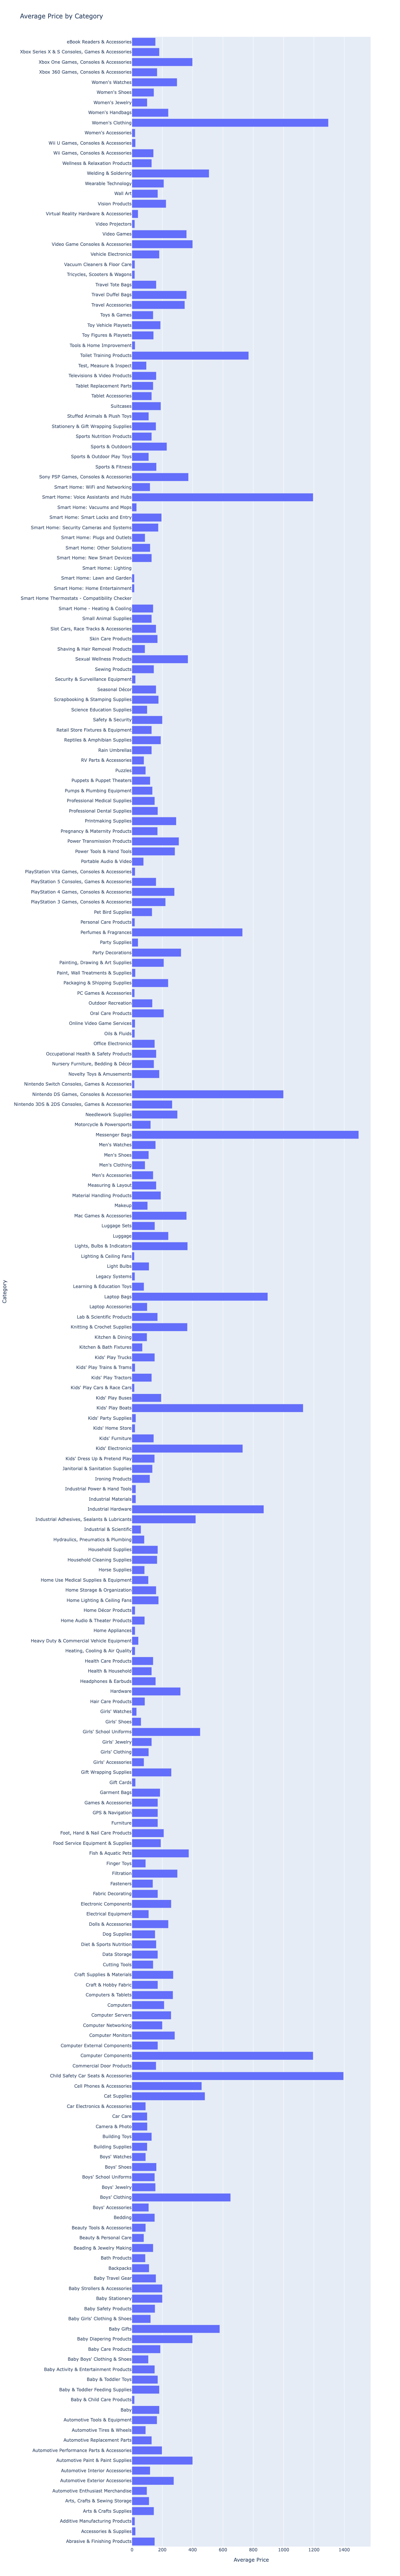

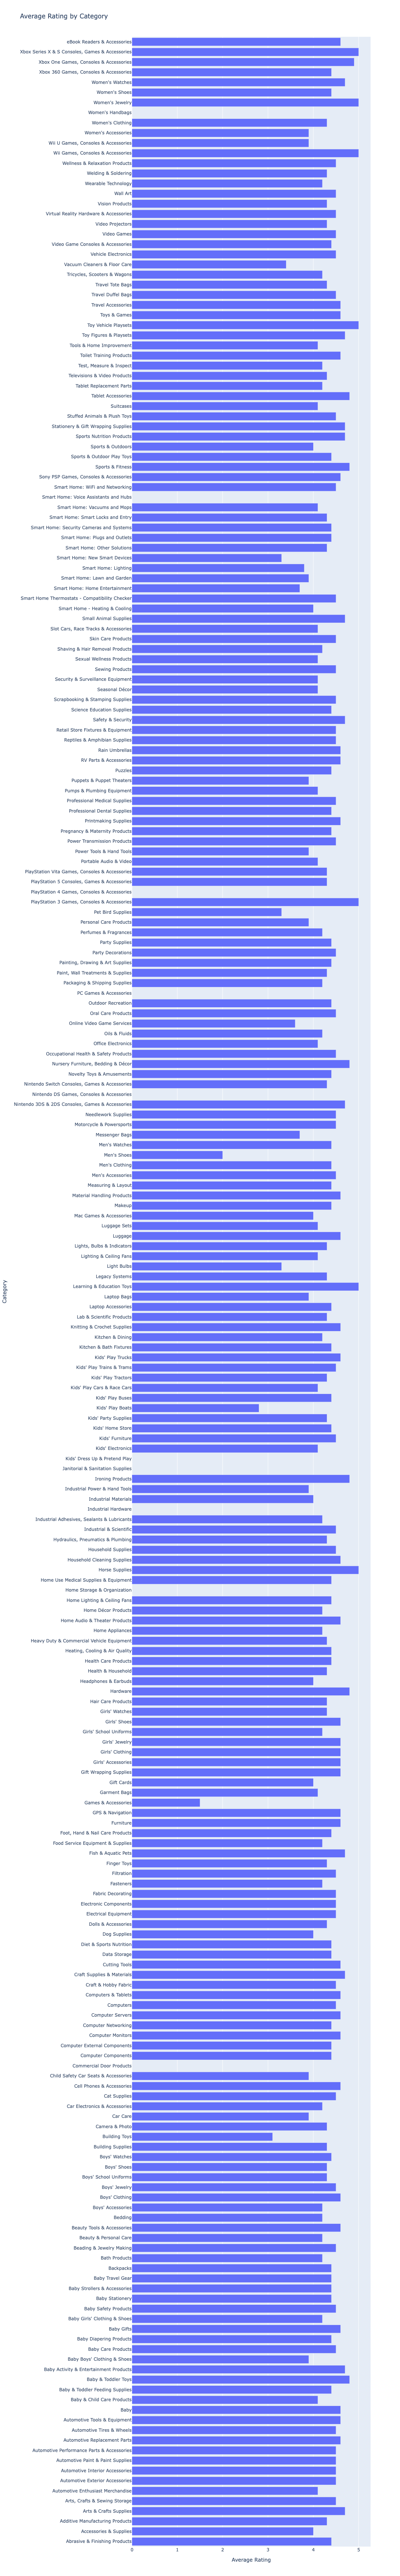

In [12]:
# . Calculate the average price and rating for products in each category
avg_price_by_category = data.groupby('category_name')['price'].mean().reset_index()
avg_price_by_category.columns = ['Category', 'Average Price']

avg_rating_by_category = data.groupby('category_name')['stars'].mean().reset_index()
avg_rating_by_category.columns = ['Category', 'Average Rating']


# . Create an interactive bar chart for average prices

fig2 = px.bar(avg_price_by_category.head(350), x='Average Price', y='Category', orientation='h',
              title='Average Price by Category',
              labels={'Average Price': 'Average Price'})
fig2.update_layout(autosize=False, width=1100, height=7000)

# . Create an interactive bar chart for average ratings
fig3 = px.bar(avg_rating_by_category.head(350), x='Average Rating', y='Category', orientation='h',
              title='Average Rating by Category',
              labels={'Average Rating': 'Average Rating'})
fig3.update_layout(autosize=False, width=1100, height=7000)

# 6. Display the interactive charts
fig2.show()
fig3.show()

In [ ]:
# Find the product with the highest rating
best_product = data[data['stars'] == data['stars'].max()]

# Print the best product information
print("Best Product with Highest Rating:")
print(best_product[['title', 'stars']])

In [ ]:
# Find the product with the highest rating
best_product = data[data['stars'] == data['stars'].max()]

# Create a textual visualization
plt.figure(figsize=(8, 4))
plt.text(0.5, 0.5, f"Best Product with Highest Rating:\n\nTitle: {best_product['title'].values[0]}\nRating: {best_product['stars'].values[0]}", 
         fontsize=14, ha='center', va='center', color='black')
plt.axis('off')
plt.show()

In [ ]:
# Find the product with the lowest rating
worst_product = data[data['stars'] == data['stars'].min()]

# Create a textual visualization for the product with the lowest rating
plt.figure(figsize=(8, 4))
plt.text(0.5, 0.5, f"Worst Product with Lowest Rating:\n\nTitle: {worst_product['title'].values[0]}\nRating: {worst_product['stars'].values[0]}", 
         fontsize=14, ha='center', va='center', color='black')
plt.axis('off')
plt.show()